In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Load CIFAR-10 (downloads automatically the first time)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Class labels
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
num_classes = len(class_names)

print("x_train:", x_train.shape, x_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_test:", x_test.shape, x_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)

# Normalize images to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes)

print("x_train (norm):", x_train.shape, x_train.dtype, "min/max:", float(x_train.min()), float(x_train.max()))
print("y_train (one-hot):", y_train_oh.shape, y_train_oh.dtype)
print("example labels:", y_train[:10].ravel())
print("example names:", [class_names[i] for i in y_train[:10].ravel()])


d:\Mamoon\Projects\CNN_cifar10\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


x_train: (50000, 32, 32, 3) uint8
y_train: (50000, 1) uint8
x_test: (10000, 32, 32, 3) uint8
y_test: (10000, 1) uint8
x_train (norm): (50000, 32, 32, 3) float32 min/max: 0.0 1.0
y_train (one-hot): (50000, 10) float64
example labels: [6 9 9 4 1 1 2 7 8 3]
example names: ['frog', 'truck', 'truck', 'deer', 'automobile', 'automobile', 'bird', 'horse', 'ship', 'cat']


In [4]:
from tensorflow import keras
from tensorflow.keras import layers

# Paper-style CNN: Conv2D -> MaxPool -> Dropout -> Dense
# (This is a common CIFAR-10 baseline that typically lands ~80-86% depending on augmentation/tuning.)

def build_cifar10_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)

model = build_cifar10_cnn(input_shape=x_train.shape[1:], num_classes=num_classes)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341,226 (5.12 MB)

 Trainable params: 1,341,226 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Train
BATCH_SIZE = 128
EPOCHS = 30  # adjust to 20–50

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=1),
]

history = model.fit(
    x_train,
    y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.3575 - loss: 1.7147 - val_accuracy: 0.5268 - val_loss: 1.3028 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.5482 - loss: 1.2551 - val_accuracy: 0.6268 - val_loss: 1.0343 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.6181 - loss: 1.0674 - val_accuracy: 0.6918 - val_loss: 0.8894 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.6663 - loss: 0.9405 - val_accuracy: 0.7146 - val_loss: 0.8197 - learning_rate: 0.0010
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.6930 - loss: 0.8638 - val_accuracy: 0.7246 - val_loss: 0.7863 - learning_rate: 0.0010
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.7204 - loss: 0.7891 - val_accuracy: 0.7518 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.7423 - l

In [6]:
# Evaluate: loss/accuracy
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc*100:.2f}%")

# Confusion matrix + Precision/Recall/F1
try:
    from sklearn.metrics import confusion_matrix, classification_report
except ImportError as e:
    raise SystemExit(
        "scikit-learn is required for confusion matrix / precision / recall / F1. "
        "Install it with: python -m pip install scikit-learn"
    ) from e

y_prob = model.predict(x_test, batch_size=256, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.reshape(-1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (rows=true, cols=pred):\n", cm)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Test loss: 0.5975
Test accuracy: 82.39%
Confusion matrix (rows=true, cols=pred):
 [[830  13  42   8  10   4   9   7  52  25]
 [  5 931   2   2   2   3   4   1  13  37]
 [ 43   1 769  28  45  31  52  20   8   3]
 [ 17   2  72 610  47 140  70  26   9   7]
 [  6   3  58  39 791  17  44  39   2   1]
 [  5   1  39  91  31 769  20  37   3   4]
 [  3   2  37  25  16  10 902   1   2   2]
 [  8   2  28  24  40  36   3 850   2   7]
 [ 32  17  10   5   6   3   5   1 912   9]
 [ 20  64   5   3   1   6   6   6  14 875]]

Classification report:
              precision    recall  f1-score   support

    airplane     0.8566    0.8300    0.8431      1000
  automobile     0.8986    0.9310    0.9145      1000
        bird     0.7241    0.7690    0.7459      1000
         cat     0.7305    0.6100    0.6649      1000
        deer     0.7998    0.7910    0.7954      1000
         dog     0.7547    0.7690    0.7618      1000
        frog     0.8090    0.9020    0.8530      1000
       horse     0.8603    0.8

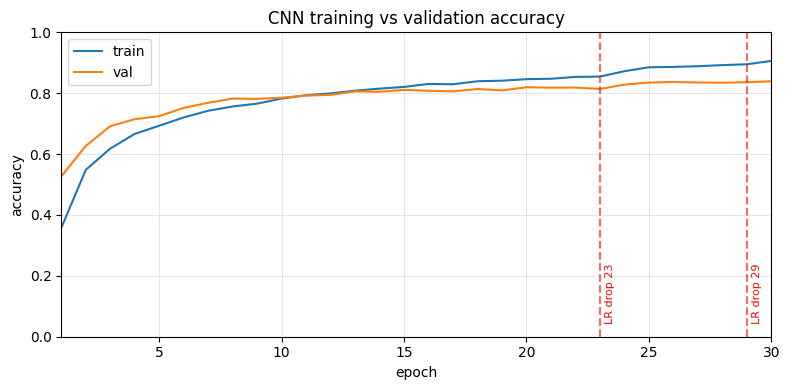

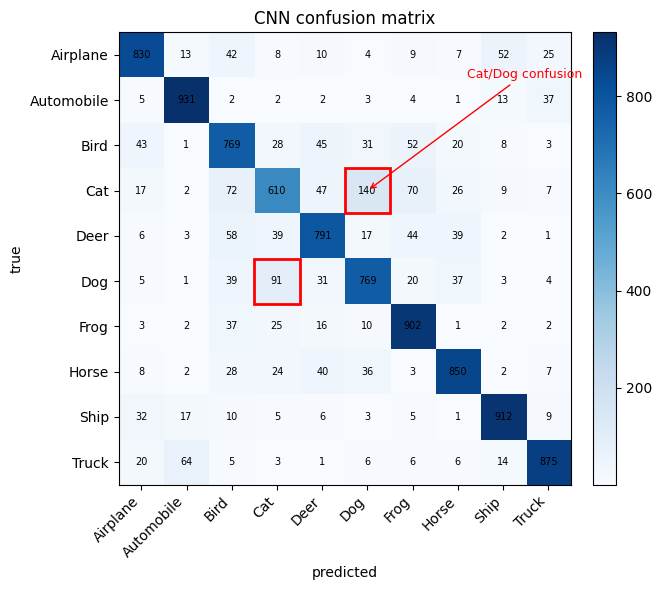

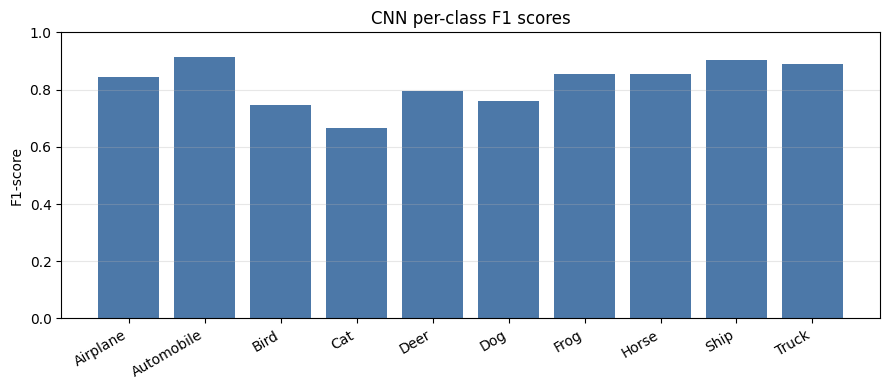

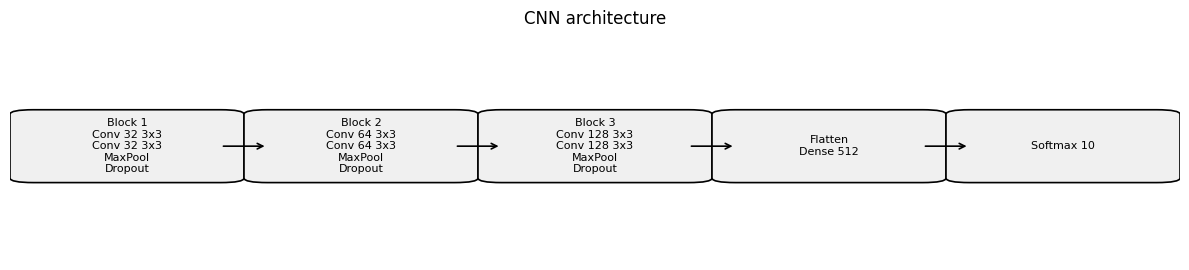

In [7]:
# Section 8 diagrams: CNN
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

if "history" not in globals():
    raise RuntimeError("Run the training cell to create history before plotting.")

acc = history.history.get("accuracy", [])
val_acc = history.history.get("val_accuracy", [])
epochs = np.arange(1, len(acc) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, acc, label="train")
if len(val_acc) == len(acc) and len(val_acc) > 0:
    ax.plot(epochs, val_acc, label="val")
ax.set_title("CNN training vs validation accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1.0)
ax.set_xlim(1, max(30, len(epochs)))
ax.grid(True, alpha=0.3)
ax.legend()

for lr_epoch in [23, 29]:
    ax.axvline(lr_epoch, color="red", linestyle="--", alpha=0.6)
    ax.text(
        lr_epoch + 0.2,
        0.05,
        f"LR drop {lr_epoch}",
        rotation=90,
        color="red",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

# Confusion matrix heatmap
y_prob = model.predict(x_test, batch_size=256, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.reshape(-1)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("CNN confusion matrix")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([n.title() for n in class_names], rotation=45, ha="right")
ax.set_yticklabels([n.title() for n in class_names])
ax.set_xlabel("predicted")
ax.set_ylabel("true")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

if "cat" in class_names and "dog" in class_names:
    cat_idx = class_names.index("cat")
    dog_idx = class_names.index("dog")
    ax.add_patch(
        Rectangle(
            (dog_idx - 0.5, cat_idx - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2
        )
    )
    ax.add_patch(
        Rectangle(
            (cat_idx - 0.5, dog_idx - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2
        )
    )
    ax.annotate(
        "Cat/Dog confusion",
        xy=(dog_idx, cat_idx),
        xytext=(dog_idx + 2.2, cat_idx - 2.5),
        arrowprops={"arrowstyle": "->", "color": "red"},
        color="red",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# Per-class F1 bar chart
report = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True, digits=4
)
f1 = [report[name]["f1-score"] for name in class_names]

x = np.arange(len(class_names))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x, f1, color="#4c78a8")
ax.set_title("CNN per-class F1 scores")
ax.set_xticks(x)
ax.set_xticklabels([n.title() for n in class_names], rotation=30, ha="right")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Architecture diagram: CNN
def add_box(ax, xy, text, width=0.16, height=0.28):
    box = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.02",
        linewidth=1.2,
        edgecolor="black",
        facecolor="#f0f0f0",
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=8,
    )


fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")
y = 0.36
w = 0.16
h = 0.28
x_positions = [0.02, 0.22, 0.42, 0.62, 0.82]
labels = [
    "Block 1\nConv 32 3x3\nConv 32 3x3\nMaxPool\nDropout",
    "Block 2\nConv 64 3x3\nConv 64 3x3\nMaxPool\nDropout",
    "Block 3\nConv 128 3x3\nConv 128 3x3\nMaxPool\nDropout",
    "Flatten\nDense 512",
    "Softmax 10",
]

for x_pos, label in zip(x_positions, labels):
    add_box(ax, (x_pos, y), label, width=w, height=h)

for i in range(len(x_positions) - 1):
    ax.annotate(
        "",
        xy=(x_positions[i + 1], y + h / 2),
        xytext=(x_positions[i] + w, y + h / 2),
        arrowprops={"arrowstyle": "->", "lw": 1.2},
    )

ax.set_title("CNN architecture")
plt.tight_layout()
plt.show()


## Step 4: Compare with paper

Paper target accuracy: **85.9%**

Fill in your achieved accuracy after training:

- Paper: **85.9%**
- Yours: **(test_acc * 100)%**

### Why your accuracy may differ

Common reasons you may land below 85.9%:

- **Data augmentation**: many strong CIFAR-10 results rely on random crop/flip (and sometimes cutout) during training.
- **Training schedule**: learning-rate schedules (step decay / cosine) and longer training often boost accuracy.
- **Regularization/normalization**: batch norm, weight decay, and tuned dropout affect generalization.
- **Architecture details**: filter counts, extra conv layers, global average pooling vs flatten, etc.
- **Reproducibility differences**: seed, preprocessing, and framework/library versions can shift results a bit.
